# Probabilistic Concept Selection

This notebook turns the selected field-development alternative into a probabilistic decision case. It calculates P10/P50/P90 NPV, tornado sensitivity, breakeven gas price and a compact risk register for concept-selection discussion.


In [1]:
from pathlib import Path
import json
import sys
import subprocess

for package in ['matplotlib', 'pandas', 'numpy']:
    try:
        __import__(package)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    NOTEBOOK_DIR = Path(__vsc_ipynb_file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd().resolve()
CHAPTER_DIR = NOTEBOOK_DIR.parent
FIGURES_DIR = CHAPTER_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
BOOK_DIR = CHAPTER_DIR
for candidate in [CHAPTER_DIR] + list(CHAPTER_DIR.parents):
    if (candidate / 'book.yaml').exists():
        BOOK_DIR = candidate
        break
PROJECT_ROOT = BOOK_DIR
for candidate in [BOOK_DIR] + list(BOOK_DIR.parents):
    if (candidate / 'pom.xml').exists() and (candidate / 'devtools' / 'neqsim_dev_setup.py').exists():
        PROJECT_ROOT = candidate
        break
sys.path.insert(0, str(PROJECT_ROOT / 'devtools'))
from neqsim_dev_setup import neqsim_init
ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False)
JClass = ns.JClass
GreenfieldConceptFactory = JClass('neqsim.process.fielddevelopment.concept.GreenfieldConceptFactory')
CashFlowEngine = JClass('neqsim.process.fielddevelopment.economics.CashFlowEngine')
SensitivityAnalyzer = JClass('neqsim.process.fielddevelopment.economics.SensitivityAnalyzer')

def update_results(section, data):
    path = BOOK_DIR / 'results.json'
    results = json.loads(path.read_text(encoding='utf-8')) if path.exists() else {}
    results[section] = data
    path.write_text(json.dumps(results, indent=2), encoding='utf-8')
    return path

print(f'Project root: {PROJECT_ROOT}')
print(f'Book directory: {BOOK_DIR}')


Project root: C:\Users\ESOL\Documents\GitHub\neqsim
Book directory: C:\Users\ESOL\Documents\GitHub\neqsim\neqsim-paperlab\books\tpg4230_field_development_and_operations_2026


## Base Case

The base case uses the standardized subsea tieback template. The same annual production profile can be replaced by a reservoir simulator export or a history-matched decline case in later course work.


In [2]:
template = GreenfieldConceptFactory.subseaTieback('Probabilistic tieback case')
start_year = 2028
gas_profile = {
    start_year + 0: 0.6e9,
    start_year + 1: 1.5e9,
    start_year + 2: 2.4e9,
    start_year + 3: 2.4e9,
    start_year + 4: 2.4e9,
    start_year + 5: 2.1e9,
    start_year + 6: 1.8e9,
    start_year + 7: 1.5e9,
    start_year + 8: 1.2e9,
    start_year + 9: 0.9e9
}

def make_engine():
    engine = CashFlowEngine('NO')
    engine.setGasPrice(0.24)
    engine.setGasTariff(0.02)
    engine.setCapex(float(template.getTotalCapexMusd()), start_year - 1)
    engine.setFixedOpexPerYear(float(template.getAnnualOpexMusd()))
    engine.setOpexPercentOfCapex(0.0)
    for year, gas in gas_profile.items():
        engine.addAnnualProduction(int(year), 0.0, float(gas), 0.0)
    return engine

engine = make_engine()
base = engine.calculate(0.08)
print(f'Base NPV: {base.getNpv():.1f} MUSD')
print(f'Base IRR: {base.getIrr() * 100.0:.1f}%')
print(f'CAPEX: {template.getTotalCapexMusd():.1f} MUSD')


Base NPV: 230.4 MUSD
Base IRR: 15.8%
CAPEX: 830.0 MUSD


In [3]:
analyzer = SensitivityAnalyzer(engine, 0.08)
tornado = analyzer.tornadoAnalysis(0.20)
tornado_rows = []
for item in tornado.getItems():
    tornado_rows.append({
        'parameter': str(item.getParameterName()),
        'low_npv_MUSD': float(item.getLowNpv()),
        'high_npv_MUSD': float(item.getHighNpv()),
        'swing_MUSD': float(item.getSwing()),
        'impact': str(item.getImpactLevel())
    })
tornado_df = pd.DataFrame(tornado_rows).sort_values('swing_MUSD')
breakeven = analyzer.breakevenAnalysis()
tornado_df


,parameter,low_npv_MUSD,high_npv_MUSD,swing_MUSD,impact
3,OPEX (%CAPEX),230.404420,230.404420,0.000000,LOW
2,Oil Price (USD/bbl),230.404420,230.404420,0.000000,LOW
1,CAPEX (MUSD),277.142836,182.066675,95.076161,MEDIUM
0,Gas Price (USD/Sm3),109.923030,346.958084,237.035054,HIGH


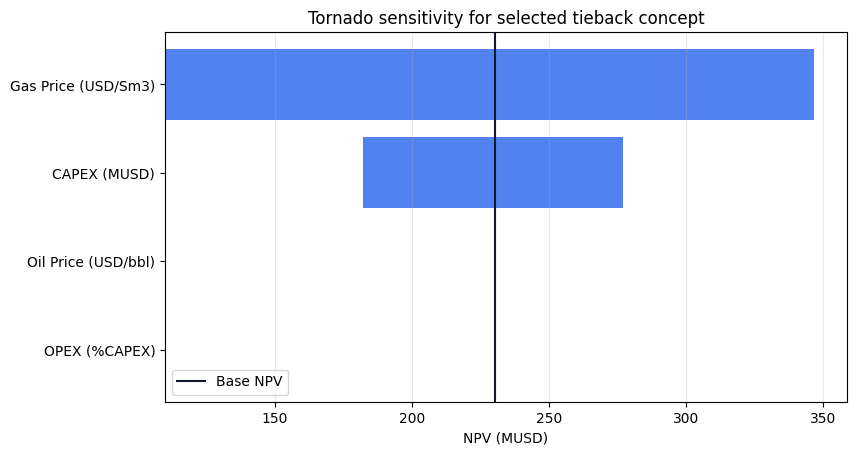

In [4]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
base_npv = float(tornado.getBaseCaseNpv())
for _, row in tornado_df.iterrows():
    left = min(row['low_npv_MUSD'], row['high_npv_MUSD'])
    width = abs(row['high_npv_MUSD'] - row['low_npv_MUSD'])
    ax.barh(row['parameter'], width, left=left, color='#2563eb', alpha=0.80)
ax.axvline(base_npv, color='#111827', linewidth=1.5, label='Base NPV')
ax.set_xlabel('NPV (MUSD)')
ax.set_title('Tornado sensitivity for selected tieback concept')
ax.grid(True, axis='x', alpha=0.3)
ax.legend()
fig.savefig(FIGURES_DIR / 'ch24_12_tornado_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


**Discussion.** *Observation.* The tornado diagram ranks the variables by NPV swing. *Mechanism.* Price and production change revenue directly, while CAPEX and OPEX change cash-flow timing and deductions. *Implication.* The most sensitive variables deserve the strongest data-quality and commercial assumptions. *Recommendation.* Put the tornado ranking beside the decision register at DG2.


In [5]:
mc_analyzer = SensitivityAnalyzer(make_engine(), 0.08)
mc_analyzer.setRandomSeed(4230)
mc_analyzer.setGasPriceDistribution(0.16, 0.34)
mc_analyzer.setCapexDistribution(float(template.getTotalCapexMusd()) * 0.75, float(template.getTotalCapexMusd()) * 1.35)
mc_analyzer.setOpexFactorDistribution(0.80, 1.25)
mc_analyzer.setProductionFactorDistribution(0.75, 1.25)
mc = mc_analyzer.monteCarloAnalysis(500)
npv_dist = [float(x) for x in mc.getNpvDistribution()]
mc_summary = {
    'npv_mean_musd': float(mc.getNpvMean()),
    'npv_std_musd': float(mc.getNpvStdDev()),
    'npv_p10_musd': float(mc.getNpvP10()),
    'npv_p50_musd': float(mc.getNpvP50()),
    'npv_p90_musd': float(mc.getNpvP90()),
    'probability_positive_npv': float(mc.getProbabilityPositiveNpv()),
    'irr_p50': float(mc.getIrrP50())
}
mc_summary


{'npv_mean_musd': 249.89569338701583,
 'npv_std_musd': 153.19396832036796,
 'npv_p10_musd': 52.97354714644584,
 'npv_p50_musd': 251.88681869025527,
 'npv_p90_musd': 455.9102722824813,
 'probability_positive_npv': 0.95,
 'irr_p50': 0.160606676801583}

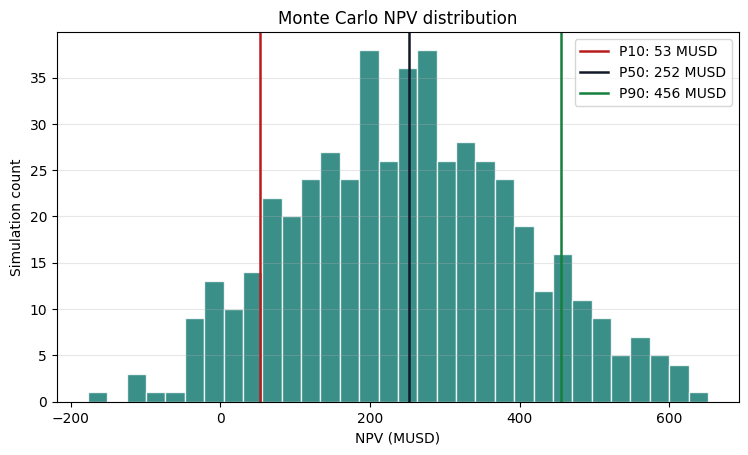

In [6]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.hist(npv_dist, bins=32, color='#0f766e', alpha=0.82, edgecolor='white')
for label, value, color in [('P10', mc_summary['npv_p10_musd'], '#b91c1c'), ('P50', mc_summary['npv_p50_musd'], '#111827'), ('P90', mc_summary['npv_p90_musd'], '#15803d')]:
    ax.axvline(value, color=color, linewidth=1.8, label=f'{label}: {value:.0f} MUSD')
ax.set_xlabel('NPV (MUSD)')
ax.set_ylabel('Simulation count')
ax.set_title('Monte Carlo NPV distribution')
ax.grid(True, axis='y', alpha=0.3)
ax.legend()
fig.savefig(FIGURES_DIR / 'ch24_12_npv_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


**Discussion.** *Observation.* The Monte Carlo distribution shows the range of plausible NPV outcomes and the probability of value creation. *Mechanism.* Price, CAPEX, OPEX and production uncertainty combine nonlinearly through the tax and discounting model. *Implication.* A concept with a high base NPV may still carry material downside. *Recommendation.* Report P10/P50/P90 and probability of positive NPV, not only the deterministic base case.


In [7]:
risk_rows = [
    {'risk': 'Gas price below planning basis', 'category': 'Market', 'likelihood': 3, 'consequence': 4, 'mitigation': 'Use price bands and sales-contract sensitivity'},
    {'risk': 'Hydrate margin insufficient in shutdown', 'category': 'Technical', 'likelihood': 3, 'consequence': 4, 'mitigation': 'Add insulation, MEG or direct electrical heating option'},
    {'risk': 'Host spare capacity unavailable at tie-in', 'category': 'Interface', 'likelihood': 2, 'consequence': 5, 'mitigation': 'Reserve capacity agreement and host bottleneck model'},
    {'risk': 'Flowline CAPEX overrun', 'category': 'Cost', 'likelihood': 3, 'consequence': 3, 'mitigation': 'Class-appropriate contingency and route survey'},
    {'risk': 'Late regulatory consent', 'category': 'Regulatory', 'likelihood': 2, 'consequence': 4, 'mitigation': 'Early authority engagement and emissions documentation'},
    {'risk': 'HSE exposure during offshore campaign', 'category': 'HSE', 'likelihood': 2, 'consequence': 4, 'mitigation': 'SIMOPS plan and installation readiness reviews'}
]
risk_df = pd.DataFrame(risk_rows)
risk_df['score'] = risk_df['likelihood'] * risk_df['consequence']
risk_df['level'] = pd.cut(risk_df['score'], bins=[0, 4, 9, 25], labels=['Low', 'Medium', 'High'])
risk_df


,risk,category,likelihood,consequence,mitigation,score,level
0,Gas price below planning basis,Market,3,4,Use price bands and sales-contract sensitivity,12,High
1,Hydrate margin insufficient in shutdown,Technical,3,4,"Add insulation, MEG or direct electrical heati...",12,High
2,Host spare capacity unavailable at tie-in,Interface,2,5,Reserve capacity agreement and host bottleneck...,10,High
3,Flowline CAPEX overrun,Cost,3,3,Class-appropriate contingency and route survey,9,Medium
4,Late regulatory consent,Regulatory,2,4,Early authority engagement and emissions docum...,8,Medium
5,HSE exposure during offshore campaign,HSE,2,4,SIMOPS plan and installation readiness reviews,8,Medium


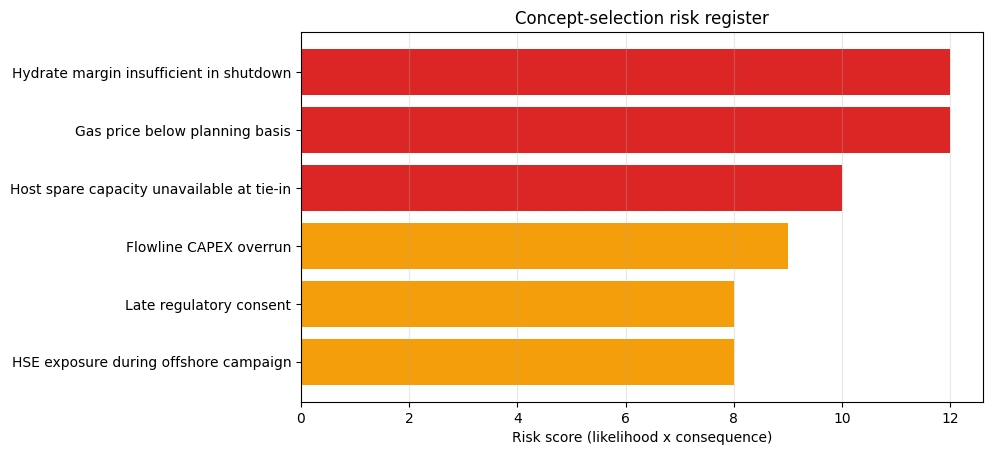

In [8]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
colors = {'Low': '#22c55e', 'Medium': '#f59e0b', 'High': '#dc2626'}
plot_df = risk_df.sort_values('score')
ax.barh(plot_df['risk'], plot_df['score'], color=[colors[str(level)] for level in plot_df['level']])
ax.set_xlabel('Risk score (likelihood x consequence)')
ax.set_title('Concept-selection risk register')
ax.grid(True, axis='x', alpha=0.3)
fig.savefig(FIGURES_DIR / 'ch24_12_risk_register.png', dpi=150, bbox_inches='tight')
plt.show()


**Discussion.** *Observation.* The largest risks combine commercial uncertainty with technical and host-interface dependencies. *Mechanism.* Brownfield concepts inherit both subsurface uncertainty and third-party host constraints. *Implication.* Risk mitigation must be tied to decision gates and commercial agreements, not only process design. *Recommendation.* Keep the risk register beside the probabilistic NPV results so decision-makers can see both upside and fragility.


In [9]:
section = {
    'base_npv_musd': float(base.getNpv()),
    'base_irr_pct': float(base.getIrr()) * 100.0,
    'breakeven_gas_price_usd_per_sm3': float(breakeven.getBreakevenGasPrice()),
    'tornado': tornado_df.sort_values('swing_MUSD', ascending=False).to_dict(orient='records'),
    'monte_carlo': mc_summary,
    'risk_register': risk_df.to_dict(orient='records'),
    'figures': [
        'figures/ch24_12_tornado_sensitivity.png',
        'figures/ch24_12_npv_distribution.png',
        'figures/ch24_12_risk_register.png'
    ]
}
results_path = update_results('probabilistic_concept_selection', section)
print(f'Updated {results_path}')
section


Updated C:\Users\ESOL\Documents\GitHub\neqsim\neqsim-paperlab\books\tpg4230_field_development_and_operations_2026\results.json


{'base_npv_musd': 230.40442023625397,
 'base_irr_pct': 15.825862400143508,
 'breakeven_gas_price_usd_per_sm3': 0.15185546875,
 'tornado': [{'parameter': 'Gas Price (USD/Sm3)',
   'low_npv_MUSD': 109.92302973776944,
   'high_npv_MUSD': 346.95808416062874,
   'swing_MUSD': 237.0350544228593,
   'impact': 'HIGH'},
  {'parameter': 'CAPEX (MUSD)',
   'low_npv_MUSD': 277.14283608962927,
   'high_npv_MUSD': 182.06667524930785,
   'swing_MUSD': 95.07616084032142,
   'impact': 'MEDIUM'},
  {'parameter': 'Oil Price (USD/bbl)',
   'low_npv_MUSD': 230.40442023625397,
   'high_npv_MUSD': 230.40442023625397,
   'swing_MUSD': 0.0,
   'impact': 'LOW'},
  {'parameter': 'OPEX (%CAPEX)',
   'low_npv_MUSD': 230.40442023625397,
   'high_npv_MUSD': 230.40442023625397,
   'swing_MUSD': 0.0,
   'impact': 'LOW'}],
 'monte_carlo': {'npv_mean_musd': 249.89569338701583,
  'npv_std_musd': 153.19396832036796,
  'npv_p10_musd': 52.97354714644584,
  'npv_p50_musd': 251.88681869025527,
  'npv_p90_musd': 455.9102722824